![BSC AI Factory — Reidentification Risk — Module 3](assets/headers/reidentification-risk.jpg)

# 02. Re-identification risk

**Topic: Module 3 · Walkthrough: Module 8, slide 4**

Link a nameless hospital table to a named demographic list, then measure how coarser fields change the matches.

**Code co-created by:** Ülkü Tuncer Küçüktaş, Simge Danışoğlu, Tolga Turan, Gizem Acer.


## Setup

Use a fresh **Python 3.11** environment. The next cell installs missing packages and corrects version mismatches.
If it installs anything, restart the kernel, then run all cells in order. Results are saved under `generated/`.


In [1]:
import subprocess
import sys
from importlib.metadata import version, PackageNotFoundError

if sys.version_info[:2] != (3, 11):
    raise RuntimeError(
        "This pinned course pack requires Python 3.11. Select a Python 3.11 kernel before installing packages."
    )

REQUIRED = {
    "numpy": "1.26.4",
    "pandas": "2.2.3",
    "scipy": "1.13.1",
    "scikit-learn": "1.5.0",
    "matplotlib": "3.9.4",
    "Faker": "37.1.0",
}


def installed_version(package):
    try:
        return version(package)
    except PackageNotFoundError:
        return None


missing = [
    f"{name}=={wanted}"
    for name, wanted in REQUIRED.items()
    if installed_version(name) != wanted
]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *missing])
    raise RuntimeError("Setup finished. Restart the kernel/runtime, then Run All.")
print("Dependencies ready:", {name: version(name) for name in REQUIRED})

Dependencies ready: {'numpy': '1.26.4', 'pandas': '2.2.3', 'scipy': '1.13.1', 'scikit-learn': '1.5.0', 'matplotlib': '3.9.4', 'Faker': '37.1.0'}


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

NAVY, BLUE, TEAL, GOLD, RED = "#1C3076", "#3457A6", "#168A88", "#C58A00", "#B53B4A"
plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.titleweight": "bold",
    }
)

from faker import Faker

OUTPUT_DIR = Path("generated/02_reidentification")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## 1. Create two synthetic tables

The hospital releases birth year, ZIP code, sex and diagnosis. A separate list contains names and
the same demographic fields for 90% of the town. An internal `person_id` is used only by the evaluator
to verify matches; it is absent from both released tables. We also discard their original row indices.


In [3]:
N_PEOPLE, PUBLIC_FRACTION, SEED = 2000, 0.9, 7
fake = Faker("en_US")
fake.seed_instance(SEED)
rng = np.random.default_rng(SEED)
people = pd.DataFrame(
    {
        "name": [fake.name() for _ in range(N_PEOPLE)],
        "birth_year": rng.integers(1945, 2006, N_PEOPLE),
        "zip": [
            region + f"{rng.integers(0,25):02d}"
            for region in rng.choice(["021", "022", "024", "908"], N_PEOPLE)
        ],
        "sex": rng.choice(["F", "M"], N_PEOPLE),
    }
)
people["diagnosis"] = rng.choice(
    ["(none)", "hypertension", "diabetes", "depression", "cancer", "HIV"],
    N_PEOPLE,
    p=[0.50, 0.16, 0.12, 0.10, 0.08, 0.04],
)
people["person_id"] = np.arange(N_PEOPLE)
QUASI_IDENTIFIERS = ["birth_year", "zip", "sex"]
hospital_private = people.sample(frac=1, random_state=2).reset_index(drop=True)
public_private = people.sample(frac=PUBLIC_FRACTION, random_state=1).reset_index(
    drop=True
)
released = hospital_private[QUASI_IDENTIFIERS + ["diagnosis"]].copy()
public = public_private[["name"] + QUASI_IDENTIFIERS].copy()
assert (
    "person_id" not in released and "person_id" not in public and "name" not in released
)
print("Hospital rows:", len(released), "| Named-list rows:", len(public))
display(released.head())
display(public.head())

Hospital rows: 2000 | Named-list rows: 1800


,birth_year,zip,sex,diagnosis
0,1999,02206,F,(none)
1,1996,90809,F,(none)
2,1956,02204,M,depression
3,1992,02219,F,(none)
4,1947,90803,M,diabetes


,name,birth_year,zip,sex
0,Caitlin Jones,1953,02214,F
1,James Barker,1949,90821,M
2,Allison Gallegos,1988,02403,F
3,Casey Kim DDS,1962,02409,F
4,Danny Davis,1978,02218,F


## 2. Match quasi-identifiers

We count a candidate only when its demographic combination appears once in each table. A separate
evaluation checks whether the candidate is the same synthetic person. In this constructed example
the public list is a subset of the same town, so matches can be verified exactly. Real lists may be
incomplete, stale or incorrect; uniqueness alone is not proof of identity.


In [4]:
def link_unique(released_table, named_table):
    """Match demographic combinations that occur exactly once in each table."""
    released_rows = released_table.copy()
    named_rows = named_table.copy()
    released_rows["release_row"] = np.arange(len(released_rows))
    named_rows["public_row"] = np.arange(len(named_rows))

    released_counts = released_rows.groupby(QUASI_IDENTIFIERS)["birth_year"].transform(
        "size"
    )
    named_counts = named_rows.groupby(QUASI_IDENTIFIERS)["birth_year"].transform("size")
    unique_released = released_rows[released_counts == 1]
    unique_named = named_rows[named_counts == 1]
    return unique_released.merge(
        unique_named, on=QUASI_IDENTIFIERS, validate="one_to_one"
    )


def verified_matches(matches):
    """Use evaluator-only identities to check the proposed links."""
    released_ids = hospital_private.iloc[
        matches.release_row.to_numpy()
    ].person_id.to_numpy()
    named_ids = public_private.iloc[matches.public_row.to_numpy()].person_id.to_numpy()
    return int((released_ids == named_ids).sum())


matches = link_unique(released, public)
group_counts = released.groupby(QUASI_IDENTIFIERS)["birth_year"].transform("size")
unique_rate = (group_counts == 1).mean()
verified = verified_matches(matches)
print(f"Unique in hospital table: {unique_rate:.1%}")
print(f"Verified links: {verified}/{N_PEOPLE} ({verified/N_PEOPLE:.1%})")
assert verified == len(matches)
display(matches[["name"] + QUASI_IDENTIFIERS + ["diagnosis"]].head(8))

Unique in hospital table: 83.8%
Verified links: 1511/2000 (75.5%)


,name,birth_year,zip,sex,diagnosis
0,Angela Walsh,1996,90809,F,(none)
1,Mrs. Jenna French,1956,02204,M,depression
2,Julie Clark,1992,02219,F,(none)
3,Teresa Maldonado,1972,90803,F,(none)
4,James Larson,1971,90813,M,hypertension
5,Carlos Evans,1975,02413,F,hypertension
6,Lindsay Kemp,1998,02218,F,(none)
7,David Franco,1999,90811,M,(none)


## 3. Generalize both sides and repeat the attack

Birth-year bands and ZIP prefixes reduce detail. We report the smallest released group size (`k`)
instead of assuming every generalization satisfies a chosen k-anonymity requirement. The measured
linkage rate concerns this attack and these fields, not every possible disclosure attack.


,level,verified_links,reidentified_percent,minimum_k,minimum_distinct_diagnoses
0,Birth year / Full ZIP,1511,75.55,1,1
1,5-year band / 4-digit ZIP,12,0.60,1,1
2,Decade / ZIP region,0,0.00,14,3
3,20-year band / ZIP region,0,0.00,17,4


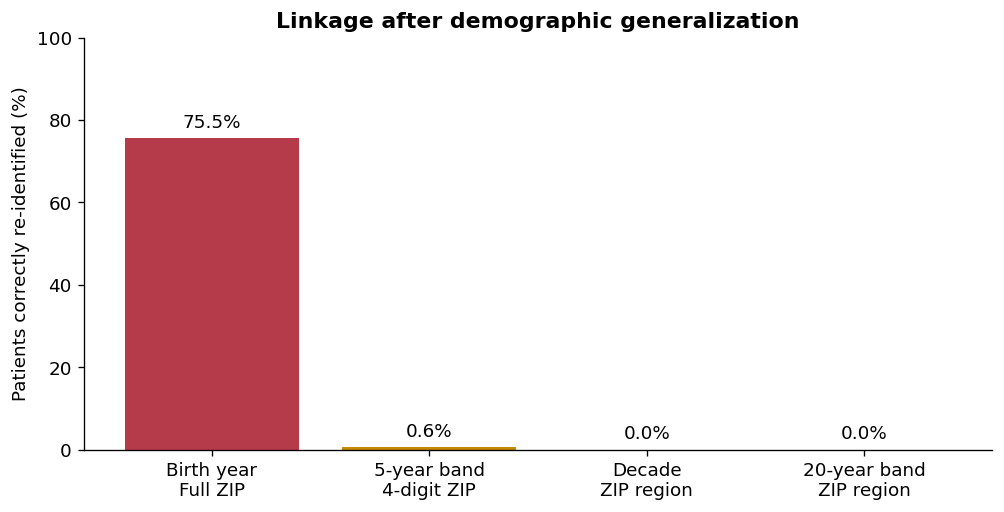

Checks passed: join keys only; every counted identity verified against hidden ground truth.


In [5]:
def generalize(frame, year_band, zip_digits):
    if year_band < 1 or zip_digits not in range(1, 6):
        raise ValueError("Invalid generalization")
    result = frame.copy()
    result["birth_year"] = (result.birth_year // year_band) * year_band
    result["zip"] = result["zip"].str[:zip_digits]
    return result


LEVELS = [
    (1, 5, "Birth year\nFull ZIP"),
    (5, 4, "5-year band\n4-digit ZIP"),
    (10, 3, "Decade\nZIP region"),
    (20, 3, "20-year band\nZIP region"),
]
rows = []
for year_band, zip_digits, label in LEVELS:
    generalized_release = generalize(released, year_band, zip_digits)
    generalized_public = generalize(public, year_band, zip_digits)
    links = link_unique(generalized_release, generalized_public)
    correct = verified_matches(links)
    sizes = generalized_release.groupby(QUASI_IDENTIFIERS).size()
    diversity = generalized_release.groupby(QUASI_IDENTIFIERS).diagnosis.nunique()
    rows.append(
        {
            "level": label.replace("\n", " / "),
            "verified_links": correct,
            "reidentified_percent": 100 * correct / N_PEOPLE,
            "minimum_k": int(sizes.min()),
            "minimum_distinct_diagnoses": int(diversity.min()),
        }
    )
results = pd.DataFrame(rows)
display(results)
assert results.verified_links.iloc[0] == verified
assert all(results.verified_links.diff().dropna() <= 0)

fig, ax = plt.subplots(figsize=(8.5, 4.4))
bars = ax.bar(
    [x[2] for x in LEVELS], results.reidentified_percent, color=[RED, GOLD, BLUE, TEAL]
)
ax.bar_label(
    bars, labels=[f"{x:.1f}%" for x in results.reidentified_percent], padding=4
)
ax.set(
    ylabel="Patients correctly re-identified (%)",
    ylim=(0, 100),
    title="Linkage after demographic generalization",
)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "linkage_by_generalization.png", bbox_inches="tight")
plt.show()
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
print(
    "Checks passed: join keys only; every counted identity verified against hidden ground truth."
)

## Experiments

1. Change `N_PEOPLE` or `PUBLIC_FRACTION`; rerun from the data cell.
2. Add a 10-year band with four ZIP digits to `LEVELS` and inspect both linkage and minimum k.
3. Compare minimum k with the number of distinct diagnoses in each group. A group can hide an exact
   identity while still revealing a diagnosis shared by everyone in it.

Reference: [Sweeney, k-anonymity (2002)](https://dataprivacylab.org/dataprivacy/projects/kanonymity/kanonymity.pdf).
